# Ejercicio 1: Intervalo IQR
A partir de siguiente código:

Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
- Indicar los nombres de los ejes.
- Incluir legenda para comprender lo que esté incluído en la gráfica.

Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final.

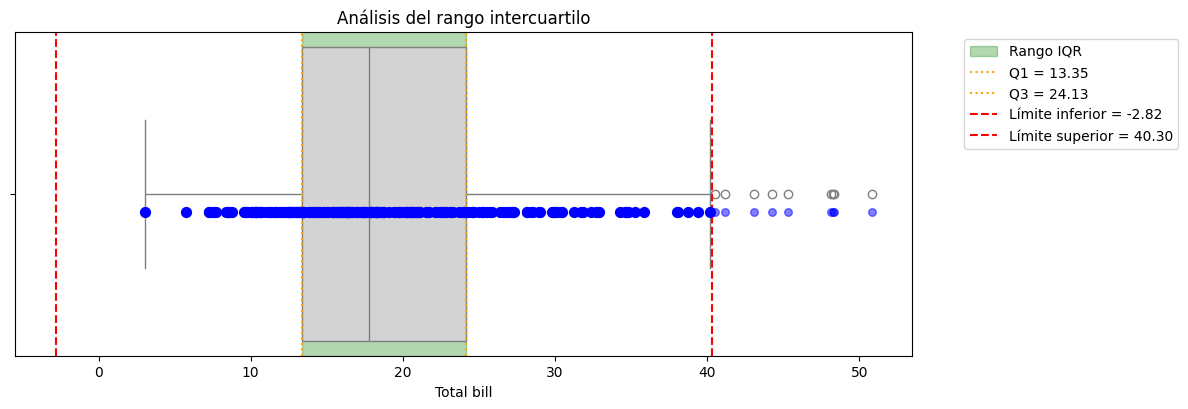

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12,4))
sns.boxplot(x=total_bill, color="lightgray")
plt.scatter(data_a, [0.05]*len(data_a), color="blue", s=30, alpha=0.5)
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5)
plt.axvspan(Q1, Q3, color='green', alpha=0.3, label='Rango IQR')
plt.axvline(Q1, color='orange', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='orange', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')
plt.title('Análisis del rango intercuartilo')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.xlabel("Total bill")
plt.show()

Las cuentas convalores superiores a 40.30 son consideradas como valores atípicos. Adicionalmente, no hay atípicos en valores inferiores al límite inferior que se encuentra por debajo de 0. Acidionalmente, la mayoría de personas tienen gastos "relativamente" bajos, que se encuentran entre 13.35 y 24.13.

# Ejercicio 2: Graficos de dispersión
A partir de siguiente código:

Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
- Indicar los nombres de los ejes
- Incluir legenda para comprender lo que esté incluído en la gráfica

Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

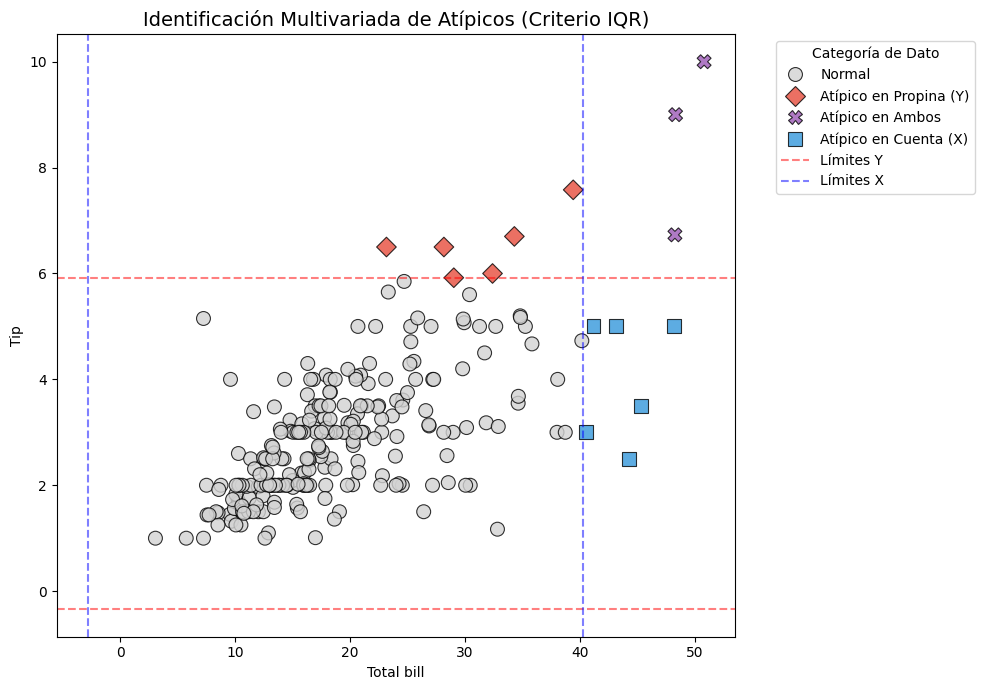

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values

# Calculo IQR
def get_limits(data):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf_x, lim_sup_x = get_limits(x)
lim_inf_y, lim_sup_y = get_limits(y)

# Clasificación
def clasificar_atipico(row):
    out_x = (row['total_bill'] < lim_inf_x) | (row['total_bill'] > lim_sup_x)
    out_y = (row['tip'] < lim_inf_y) | (row['tip'] > lim_sup_y)

    if out_x and out_y: return 'Atípico en Ambos'
    if out_x: return 'Atípico en Cuenta (X)'
    if out_y: return 'Atípico en Propina (Y)'
    return 'Normal'

# Aplicamos la clasificación en una sola columna
tips['Tipo_Punto'] = tips.apply(clasificar_atipico, axis=1)

# --- Gráfica ---
plt.figure(figsize=(10, 7))

# Usamos paleta y marcadores personalizados para que resalten
palette = {
    'Normal': 'lightgrey',
    'Atípico en Cuenta (X)': '#3498db', # Azul
    'Atípico en Propina (Y)': '#e74c3c', # Rojo
    'Atípico en Ambos': '#9b59b6'       # Morado
}

markers = {
    'Normal': 'o',
    'Atípico en Cuenta (X)': 's', # Cuadrado
    'Atípico en Propina (Y)': 'D', # Diamante
    'Atípico en Ambos': 'X'        # X gruesa
}

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='Tipo_Punto',
    style='Tipo_Punto',
    palette=palette,
    markers=markers,
    s=100,
    edgecolor='black',
    alpha=0.8
)

# Líneas de límites
plt.axhline(lim_sup_y, color='red', linestyle='--', alpha=0.5, label='Límites Y')
plt.axhline(lim_inf_y, color='red', linestyle='--', alpha=0.5)
plt.axvline(lim_sup_x, color='blue', linestyle='--', alpha=0.5, label='Límites X')
plt.axvline(lim_inf_x, color='blue', linestyle='--', alpha=0.5)

plt.title("Identificación Multivariada de Atípicos (Criterio IQR)", fontsize=14)
plt.legend(title='Categoría de Dato', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.tight_layout()
plt.show()

Luego de calcular los atípicos a partir del IQR aplicado sobre la variable "Tip" se puede observar que las propinas altas no son tan comunes respecto a las propinas por debajo de 6, pero cuando se calculan los outliers respecto al IQR de "Total bill" se encuentran outliers en cuentas superiores a 40, entonces, el conjunto de outliers de anbas variables se vuelve importante porque puede tener presente el comportamiento de los datos de una manera más general (o integrativa) y al final, se pueden tomar como outliers para el porblema aquellos datos que son outliers para ambas varibales (los 3 datos que se encuentran en la parte superior derecha), donde se evidencian cuentas altas con propinas también altas.

# Ejercicio 3: Histogramas y funciones de densidad
A partir de siguiente código:

Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
- Indicar los nombres de los ejes
- Incluir legenda para comprender lo que esté incluído en la gráfica

Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

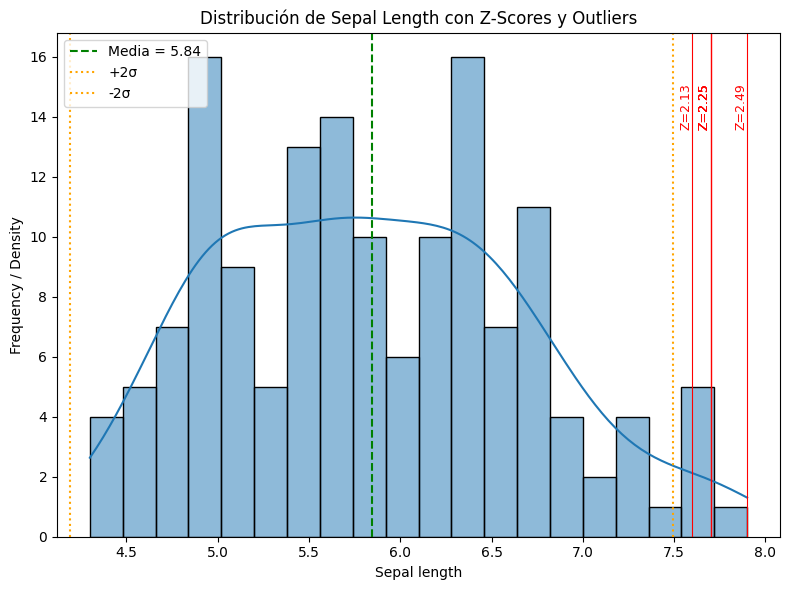

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats # Import stats module

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# Calcular Z-scores
z_scores = stats.zscore(x)
outliers = x[np.abs(z_scores) > 2]
outliers_z = z_scores[np.abs(z_scores) > 2]

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True)

# Líneas de referencia on current plt
plt.axvline(np.mean(x), color="green", linestyle="--", label=f"Media = {np.mean(x):.2f}")
plt.axvline(np.mean(x) + 2*np.std(x), color="orange", linestyle=":", label="+2σ")
plt.axvline(np.mean(x) - 2*np.std(x), color="orange", linestyle=":", label="-2σ")

# Outliers con anotación de Z-score on current axes (plt)
for out, z in zip(outliers, outliers_z):
    plt.axvline(out, color="red", linestyle="-", linewidth=0.8)
    plt.text(out, plt.gca().get_ylim()[1] * 0.9, f"Z={z:.2f}", rotation=90, color="red", fontsize=9, ha='right', va='top')

plt.title('Distribución de Sepal Length con Z-Scores y Outliers')
plt.xlabel("Sepal length")
plt.ylabel("Frequency / Density")
plt.legend()
plt.tight_layout()
plt.show()

Se observa que respecto a la longitud del sépalo presenta outliers con z=2, donde se encuentran dos outliers con valores superiores a 7.5, sin embargo, no son tan alejados, lo que podría hacer considerar incluir los datos (esto debido a que z=2 es muy pequeño y recoje la mayor cantidad de datos).

# Ejercicio 4: Z-Score
A partir de siguiente código:

Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
- Indicar los nombres de los ejes
- Incluir legenda para comprender lo que esté incluído en la gráfica

Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

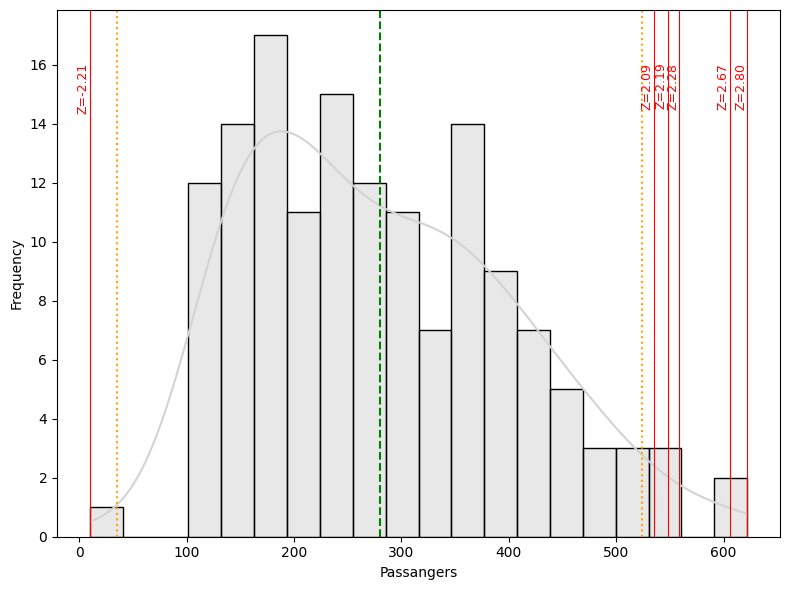

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, color="lightgray")
plt.scatter(x[data_b], np.zeros_like(x[data_b]), color="red", s=50, marker=" ")
plt.ylabel("Frequency")
plt.xlabel("Passangers")
plt.tight_layout()
plt.axvline(np.mean(x), color="green", linestyle="--", label=f"Media = {np.mean(x):.2f}")
plt.axvline(np.mean(x) + 2*np.std(x), color="orange", linestyle=":", label="+2σ")
plt.axvline(np.mean(x) - 2*np.std(x), color="orange", linestyle=":", label="-2σ")
for out, z in zip(outliers, outliers_z):
    plt.axvline(out, color="red", linestyle="-", linewidth=0.8)
    plt.text(out, plt.gca().get_ylim()[1] * 0.9, f"Z={z:.2f}", rotation=90, color="red", fontsize=9, ha='right', va='top')
plt.show()

En la gráfica se observa que la mayoría de datos se encuentran entre 100 y 500 pasajeros, con algunos datos que pueden considerarse outliers cuando z=2, sin embargo, el hecho de que sean tan cercanos al z objetivo y que no tienen valores tan extremos como si se determinaran con un valor de z=3.